<a href="https://colab.research.google.com/github/israrahmadzak/diabetes-xai-mphil/blob/main/framework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os

for file in sorted(os.listdir()):
    print(file)

.config
sample_data


In [6]:
for file in sorted(os.listdir()):
    print(file)

.config
sample_data


In [2]:
import pandas as pd
import numpy as np

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
demo    = pd.read_sas("DEMO_J.xpt")
bmx     = pd.read_sas("BMX_J.xpt")
bpx     = pd.read_sas("BPX_J.xpt")
glu     = pd.read_sas("GLU_J.xpt")
ghb     = pd.read_sas("GHB_J.xpt")
hdl     = pd.read_sas("HDL_J.xpt")
tchol   = pd.read_sas("TCHOL_J.xpt")
trigly  = pd.read_sas("TRIGLY_J.xpt")
diq     = pd.read_sas("DIQ_J.xpt")
smq     = pd.read_sas("SMQ_J.xpt")
paq     = pd.read_sas("PAQ_J.xpt")
alq     = pd.read_sas("ALQ_J.xpt")
acq     = pd.read_sas("ACQ_J.xpt")

FileNotFoundError: [Errno 2] No such file or directory: 'DEMO_J.xpt'

In [5]:
datasets = {
    "DEMO": demo,
    "BMX": bmx,
    "BPX": bpx,
    "GLU": glu,
    "GHB": ghb,
    "HDL": hdl,
    "TCHOL": tchol,
    "TRIGLY": trigly,
    "DIQ": diq,
    "SMQ": smq,
    "PAQ": paq,
    "ALQ": alq,
    "ACQ": acq
}

for name, df in datasets.items():
    print(f"{name:8} Shape: {df.shape}")

DEMO     Shape: (9254, 46)
BMX      Shape: (8704, 21)
BPX      Shape: (8704, 21)
GLU      Shape: (3036, 4)
GHB      Shape: (6401, 2)
HDL      Shape: (7435, 3)
TCHOL    Shape: (7435, 3)
TRIGLY   Shape: (3036, 10)
DIQ      Shape: (8897, 54)
SMQ      Shape: (6724, 37)
PAQ      Shape: (5856, 17)
ALQ      Shape: (5533, 10)
ACQ      Shape: (8421, 6)


In [6]:
for name, df in datasets.items():
    print(f"{name}: {'SEQN' in df.columns}")

DEMO: True
BMX: True
BPX: True
GLU: True
GHB: True
HDL: True
TCHOL: True
TRIGLY: True
DIQ: True
SMQ: True
PAQ: True
ALQ: True
ACQ: True


In [7]:
# Start with demographics
df = demo.copy()

# Merge remaining datasets
df = df.merge(bmx, on="SEQN", how="left")
df = df.merge(bpx, on="SEQN", how="left")
df = df.merge(glu, on="SEQN", how="left")
df = df.merge(ghb, on="SEQN", how="left")
df = df.merge(hdl, on="SEQN", how="left")
df = df.merge(tchol, on="SEQN", how="left")
df = df.merge(trigly, on="SEQN", how="left")
df = df.merge(diq, on="SEQN", how="left")
df = df.merge(smq, on="SEQN", how="left")
df = df.merge(paq, on="SEQN", how="left")
df = df.merge(alq, on="SEQN", how="left")
df = df.merge(acq, on="SEQN", how="left")

print("Merged dataset shape:", df.shape)

Merged dataset shape: (9254, 222)


In [8]:
# Find duplicate column names
duplicates = df.columns[df.columns.duplicated()]

print("Duplicate columns:", list(duplicates))
print("Number of duplicate columns:", len(duplicates))

Duplicate columns: []
Number of duplicate columns: 0


In [9]:
print(df.head())

print("\n")
print(df.info())

      SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  93703.0      10.0       2.0       2.0       2.0       NaN       5.0   
1  93704.0      10.0       2.0       1.0       2.0       NaN       3.0   
2  93705.0      10.0       2.0       2.0      66.0       NaN       4.0   
3  93706.0      10.0       2.0       1.0      18.0       NaN       5.0   
4  93707.0      10.0       2.0       1.0      13.0       NaN       5.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  DMQMILIZ  DMQADFC  DMDBORN4  DMDCITZN  \
0       6.0       2.0      27.0       NaN      NaN       1.0       1.0   
1       3.0       1.0      33.0       NaN      NaN       1.0       1.0   
2       4.0       2.0       NaN       2.0      NaN       1.0       1.0   
3       6.0       2.0     222.0       2.0      NaN       1.0       1.0   
4       7.0       2.0     158.0       NaN      NaN       1.0       1.0   

   DMDYRSUS  DMDEDUC3  DMDEDUC2  DMDMARTL  RIDEXPRG  SIALANG  SIAPROXY  \
0       NaN       NaN       NaN     

In [10]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="Missing Values")
)

missing["Percent Missing"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing.head(30)

,Missing Values,Percent Missing
BMIHEAD,9254,100.00
SMQ665B,9253,99.99
DIQ175X,9252,99.98
SMQ665D,9252,99.98
SMQ665A,9251,99.97
SMQ665C,9250,99.96
DIQ175W,9249,99.95
DIQ175V,9240,99.85
SMQ661,9240,99.85
ACD011B,9238,99.83


In [11]:
candidate_features = [

    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",

    "BMXBMI",
    "BMXWAIST",

    "BPXSY1",
    "BPXDI1",

    "LBXGLU",
    "LBXGH",

    "LBDHDD",
    "LBXTC",
    "LBXTR",

    "SMQ020",

    "ALQ101",

    "PAQ650",
    "PAQ665",

    "DIQ010"

]

summary = pd.DataFrame({

    "Missing": df[candidate_features].isnull().sum(),

    "Missing %": (
        df[candidate_features].isnull().mean()*100
    ).round(2),

    "Unique Values": df[candidate_features].nunique()

})

summary

KeyError: "['ALQ101'] not in index"

In [12]:
# Show all columns in the Alcohol questionnaire
alq.columns.tolist()

['SEQN',
 'ALQ111',
 'ALQ121',
 'ALQ130',
 'ALQ142',
 'ALQ270',
 'ALQ280',
 'ALQ290',
 'ALQ151',
 'ALQ170']

In [13]:
# Show all columns in the Physical Activity questionnaire
paq.columns.tolist()

['SEQN',
 'PAQ605',
 'PAQ610',
 'PAD615',
 'PAQ620',
 'PAQ625',
 'PAD630',
 'PAQ635',
 'PAQ640',
 'PAD645',
 'PAQ650',
 'PAQ655',
 'PAD660',
 'PAQ665',
 'PAQ670',
 'PAD675',
 'PAD680']

In [14]:
# Show all columns in the Smoking questionnaire
smq.columns.tolist()

['SEQN',
 'SMQ020',
 'SMD030',
 'SMQ040',
 'SMQ050Q',
 'SMQ050U',
 'SMD057',
 'SMQ078',
 'SMD641',
 'SMD650',
 'SMD093',
 'SMDUPCA',
 'SMD100BR',
 'SMD100FL',
 'SMD100MN',
 'SMD100LN',
 'SMD100TR',
 'SMD100NI',
 'SMD100CO',
 'SMQ621',
 'SMD630',
 'SMQ661',
 'SMQ665A',
 'SMQ665B',
 'SMQ665C',
 'SMQ665D',
 'SMQ670',
 'SMQ848',
 'SMQ852Q',
 'SMQ852U',
 'SMQ890',
 'SMQ895',
 'SMQ900',
 'SMQ905',
 'SMQ910',
 'SMQ915',
 'SMAQUEX2']

In [15]:
alq.describe(include='all')

,SEQN,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170
count,5533.000000,5130.000000,4.545000e+03,3495.000000,3.495000e+03,1.439000e+03,1.439000e+03,5.220000e+02,4544.000000,3.487000e+03
mean,98275.674679,1.114035,4.984378e+00,4.163948,3.260944e+00,4.186240e+00,3.186935e+00,4.505747e+00,1.860695,1.008661e+01
std,2685.591411,0.317885,4.320915e+00,39.932804,6.097613e+00,8.673497e+00,7.441787e+00,9.820313e+00,0.447760,8.888098e+01
min,93705.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000,5.397605e-79
25%,95945.000000,1.000000,1.000000e+00,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,2.000000,5.397605e-79
50%,98257.000000,1.000000,5.000000e+00,2.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,2.000000,5.397605e-79
75%,100590.000000,1.000000,8.000000e+00,3.000000,7.000000e+00,8.000000e+00,7.000000e+00,8.000000e+00,2.000000,1.000000e+00
max,102956.000000,2.000000,9.900000e+01,999.000000,9.900000e+01,9.900000e+01,9.900000e+01,9.900000e+01,9.000000,9.990000e+02


In [16]:
candidate_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",

    "BMXBMI",
    "BMXWAIST",

    "BPXSY1",
    "BPXDI1",

    "LBXGLU",
    "LBXGH",

    "LBDHDD",
    "LBXTC",
    "LBXTR",

    "SMQ020",

    "PAQ650",
    "PAQ665",

    "DIQ010"
]

summary = pd.DataFrame({
    "Missing": df[candidate_features].isnull().sum(),
    "Missing %": (df[candidate_features].isnull().mean()*100).round(2),
    "Unique Values": df[candidate_features].nunique(),
    "Data Type": df[candidate_features].dtypes.astype(str)
})

summary

,Missing,Missing %,Unique Values,Data Type
RIDAGEYR,0,0.00,81,float64
RIAGENDR,0,0.00,2,float64
RIDRETH3,0,0.00,6,float64
DMDEDUC2,3685,39.82,7,float64
INDFMPIR,1231,13.30,445,float64
BMXBMI,1249,13.50,440,float64
BMXWAIST,1653,17.86,1035,float64
BPXSY1,2952,31.90,71,float64
BPXDI1,2952,31.90,56,float64
LBXGLU,6363,68.76,207,float64


In [17]:
# ============================
# Model A (Minimal Clinical)
# ============================

model_A = [
    "RIDAGEYR",      # Age
    "RIAGENDR",      # Gender
    "BMXBMI",        # BMI
    "LBXGLU",        # Fasting Glucose
    "DIQ010"         # Target
]

# ============================
# Model B (Extended Clinical)
# ============================

model_B = [
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "DIQ010"
]

# ============================
# Model C (Comprehensive)
# ============================

model_C = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "SMQ020",
    "PAQ650",
    "PAQ665",
    "DIQ010"
]

In [18]:
print("="*50)

print("Model A")
print(df[model_A].dropna().shape)

print("="*50)

print("Model B")
print(df[model_B].dropna().shape)

print("="*50)

print("Model C")
print(df[model_C].dropna().shape)

Model A
(2842, 5)
Model B
(2424, 11)
Model C
(1781, 17)


In [19]:
total = len(df)

for name, cols in {
    "Model A": model_A,
    "Model B": model_B,
    "Model C": model_C
}.items():

    n = df[cols].dropna().shape[0]

    print(f"{name}")
    print(f"Participants = {n}")
    print(f"Percentage = {100*n/total:.2f}%")
    print("-"*40)

Model A
Participants = 2842
Percentage = 30.71%
----------------------------------------
Model B
Participants = 2424
Percentage = 26.19%
----------------------------------------
Model C
Participants = 1781
Percentage = 19.25%
----------------------------------------


In [20]:
framework1 = df[
    [
        "RIDAGEYR",   # Age
        "RIAGENDR",   # Gender
        "BMXBMI",     # BMI
        "LBXGLU",     # Fasting Glucose
        "DIQ010"      # Diabetes target
    ]
].copy()

print(framework1.shape)
framework1.head()

(9254, 5)


,RIDAGEYR,RIAGENDR,BMXBMI,LBXGLU,DIQ010
0,2.0,2.0,17.5,NaN,2.0
1,2.0,1.0,15.7,NaN,2.0
2,66.0,2.0,31.7,NaN,2.0
3,18.0,1.0,21.5,NaN,2.0
4,13.0,1.0,18.1,NaN,2.0


In [21]:
framework1["DIQ010"].value_counts(dropna=False).sort_index()

,count
DIQ010,
1.0,893
2.0,7816
3.0,184
9.0,4
NaN,357


In [22]:
# Keep only Yes and No responses
framework1 = framework1[framework1["DIQ010"].isin([1, 2])].copy()

# Create binary target
framework1["diabetes"] = framework1["DIQ010"].map({
    1: 1,
    2: 0
})

# Drop original target column
framework1.drop(columns=["DIQ010"], inplace=True)

print(framework1.shape)

framework1["diabetes"].value_counts()

(8709, 5)


,count
diabetes,
0,7816
1,893


In [23]:
framework1.isnull().sum()

,0
RIDAGEYR,0
RIAGENDR,0
BMXBMI,881
LBXGLU,5903
diabetes,0


In [24]:
framework1.isnull().sum()

,0
RIDAGEYR,0
RIAGENDR,0
BMXBMI,881
LBXGLU,5903
diabetes,0


In [25]:
# Keep only participants with available glucose
framework1 = framework1.dropna(subset=["LBXGLU"])

print("Framework 1 shape:", framework1.shape)

print("\nMissing values:")
print(framework1.isnull().sum())

Framework 1 shape: (2806, 5)

Missing values:
RIDAGEYR     0
RIAGENDR     0
BMXBMI      48
LBXGLU       0
diabetes     0
dtype: int64


In [26]:
models = {
    "Logistic Regression": ...,
    "Random Forest": ...,
    "SVM": ...,
    "XGBoost": ...
}

In [27]:
# Features
X = framework1[["RIDAGEYR", "RIAGENDR", "BMXBMI", "LBXGLU"]]

# Target
y = framework1["diabetes"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2806, 4)
Target shape: (2806,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (2244, 4)
Testing : (562, 4)


In [29]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
diabetes
0    1911
1     333
Name: count, dtype: int64

Testing class distribution:
diabetes
0    479
1     83
Name: count, dtype: int64


In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# Fit only on training data
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

# Transform test data
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print(X_train.isnull().sum())
print(X_test.isnull().sum())

RIDAGEYR    0
RIAGENDR    0
BMXBMI      0
LBXGLU      0
dtype: int64
RIDAGEYR    0
RIAGENDR    0
BMXBMI      0
LBXGLU      0
dtype: int64


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (2244, 4)
Scaled testing shape : (562, 4)


In [32]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
diabetes
0    1911
1     333
Name: count, dtype: int64

Testing class distribution:
diabetes
0    479
1     83
Name: count, dtype: int64


In [33]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [34]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [35]:
y_pred = lr.predict(X_test_scaled)

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

Accuracy : 0.8985765124555161
Precision: 0.7954545454545454
Recall   : 0.42168674698795183
F1-score : 0.5511811023622047
ROC-AUC  : 0.919586487914078
PR-AUC   : 0.6843405970588431


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       479
           1       0.80      0.42      0.55        83

    accuracy                           0.90       562
   macro avg       0.85      0.70      0.75       562
weighted avg       0.89      0.90      0.88       562



In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [39]:
models = {

    "Logistic Regression":
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42,
            n_estimators=200
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

In [40]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score
)

In [41]:
results = []

In [42]:
for name, model in models.items():

    print("="*60)

    print(name)

    # Scaling only for LR and SVM
    if name in ["Logistic Regression", "SVM"]:

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

        prob = model.predict_proba(X_test_scaled)[:,1]

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        prob = model.predict_proba(X_test)[:,1]


    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(y_test,pred),

        "Recall":recall_score(y_test,pred),

        "F1":f1_score(y_test,pred),

        "ROC_AUC":roc_auc_score(y_test,prob),

        "PR_AUC":average_precision_score(y_test,prob)

    })

Logistic Regression
Random Forest
SVM
XGBoost


In [43]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.898577,0.795455,0.421687,0.551181,0.919586,0.684341
1,Random Forest,0.907473,0.746032,0.566265,0.643836,0.890535,0.639176
3,XGBoost,0.887900,0.651515,0.518072,0.577181,0.888498,0.597713
2,SVM,0.898577,0.770833,0.445783,0.564885,0.842267,0.642642


In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [46]:
from sklearn.linear_model import LogisticRegression

lr_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lr_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(lr_search.best_params_)

print("\nBest CV ROC-AUC:")
print(lr_search.best_score_)

Best Parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV ROC-AUC:
0.9216832566488297


In [47]:
from sklearn.model_selection import GridSearchCV

def tune_model(model, param_grid, X, y, cv, scoring="roc_auc"):

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X, y)

    print("=" * 60)
    print(type(model).__name__)
    print("Best Parameters:")
    print(grid.best_params_)
    print("Best CV ROC-AUC:")
    print(round(grid.best_score_, 4))

    return grid

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = tune_model(
    RandomForestClassifier(random_state=42),
    rf_grid,
    X_train,
    y_train,
    cv
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
RandomForestClassifier
Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC:
0.9307


In [49]:
from sklearn.svm import SVC

svm_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_search = tune_model(
    SVC(probability=True, random_state=42),
    svm_grid,
    X_train_scaled,
    y_train,
    cv
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVC
Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV ROC-AUC:
0.9184


In [50]:
from xgboost import XGBClassifier

xgb_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_search = tune_model(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_grid,
    X_train,
    y_train,
    cv
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
XGBClassifier
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC:
0.9314


In [51]:
# Best tuned Random Forest
best_rf = rf_search.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.905693950177936
Precision: 0.7678571428571429
Recall   : 0.5180722891566265
F1-score : 0.6187050359712231
ROC-AUC  : 0.9182785421435218
PR-AUC   : 0.6842124075756926

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       479
           1       0.77      0.52      0.62        83

    accuracy                           0.91       562
   macro avg       0.84      0.75      0.78       562
weighted avg       0.90      0.91      0.90       562



In [52]:
def evaluate_model(name, model, X_test, y_test):
    ...

In [53]:
from xgboost import XGBClassifier

xgb_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = tune_model(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_grid,
    X_train,
    y_train,
    cv
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBClassifier
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC:
0.9323


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(name, model, X_test, y_test):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob)
    }

In [55]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        lr_search.best_estimator_,
        X_test_scaled,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_search.best_estimator_,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "SVM",
        svm_search.best_estimator_,
        X_test_scaled,
        y_test
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        xgb_search.best_estimator_,
        X_test,
        y_test
    )
)

results_df = pd.DataFrame(results)
results_df.sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.895018,0.833333,0.361446,0.504202,0.919536,0.683641
1,Random Forest,0.905694,0.767857,0.518072,0.618705,0.918279,0.684212
2,SVM,0.895018,0.785714,0.397590,0.528000,0.917625,0.693159
3,XGBoost,0.900356,0.745455,0.493976,0.594203,0.916078,0.685275


In [57]:
# Best tuned Random Forest
best_rf = rf_search.best_estimator_

# Predicted probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [58]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

thresholds = np.arange(0.30, 0.75, 0.05)

results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fnr = fn / (fn + tp)

    results.append({
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "False Negative Rate": fnr
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1,False Negative Rate
0,0.30,0.903915,0.683544,0.650602,0.666667,0.349398
1,0.35,0.907473,0.718310,0.614458,0.662338,0.385542
2,0.40,0.911032,0.753846,0.590361,0.662162,0.409639
3,0.45,0.909253,0.766667,0.554217,0.643357,0.445783
4,0.50,0.905694,0.767857,0.518072,0.618705,0.481928
5,0.55,0.900356,0.754717,0.481928,0.588235,0.518072
6,0.60,0.893238,0.755556,0.409639,0.531250,0.590361
7,0.65,0.895018,0.785714,0.397590,0.528000,0.602410
8,0.70,0.891459,0.775000,0.373494,0.504065,0.626506


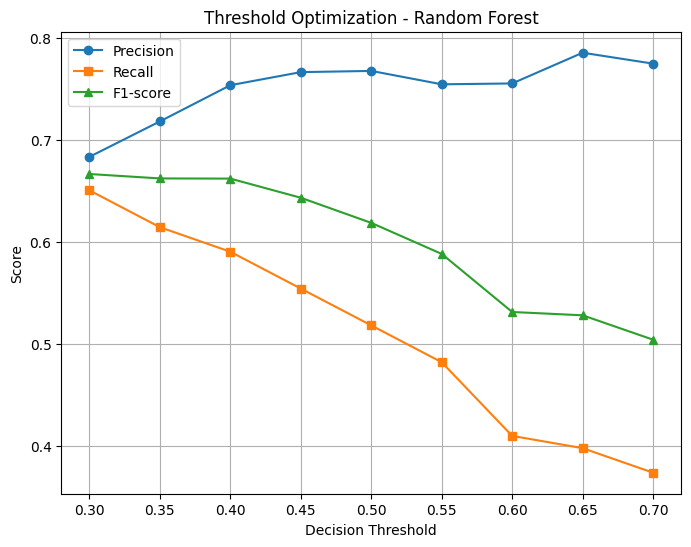

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(threshold_results["Threshold"],
         threshold_results["Precision"],
         marker="o",
         label="Precision")

plt.plot(threshold_results["Threshold"],
         threshold_results["Recall"],
         marker="s",
         label="Recall")

plt.plot(threshold_results["Threshold"],
         threshold_results["F1"],
         marker="^",
         label="F1-score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization - Random Forest")
plt.grid(True)
plt.legend()

plt.show()

In [60]:
features_f2 = [
    "RIDAGEYR",   # Age
    "RIAGENDR",   # Gender
    "BMXBMI",     # BMI
    "BMXWAIST",   # Waist circumference
    "BPXSY1",     # Systolic BP
    "BPXDI1",     # Diastolic BP
    "LBDHDD",     # HDL
    "LBXTC",      # Total Cholesterol
    "LBXTR"       # Triglycerides
]

In [61]:
df[features_f2 + ["DIQ010"]].isnull().sum()

,0
RIDAGEYR,0
RIAGENDR,0
BMXBMI,1249
BMXWAIST,1653
BPXSY1,2952
BPXDI1,2952
LBDHDD,2516
LBXTC,2516
LBXTR,6420
DIQ010,357


In [62]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_f2 = df[features_f2]
y = df["DIQ010"]

X_f2_imputed = pd.DataFrame(
    imputer.fit_transform(X_f2),
    columns=features_f2
)

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_f2_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [64]:
df_clean = df.copy()

df_clean = df_clean[df_clean["DIQ010"].notna()]

In [65]:
df_clean["diabetes"] = df_clean["DIQ010"].map({
    1: 1,   # Diabetes
    2: 0    # No diabetes
})

In [66]:
df_clean = df_clean[df_clean["diabetes"].isin([0,1])]

In [67]:
X_f2 = df_clean[features_f2]
y = df_clean["diabetes"]

In [68]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_f2_imputed = pd.DataFrame(
    imputer.fit_transform(X_f2),
    columns=features_f2
)

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_f2_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
results_f2 = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results_f2.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob)
    })

pd.DataFrame(results_f2).sort_values("ROC_AUC", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.892078,0.421053,0.134078,0.203390,0.865679,0.403442
1,Random Forest,0.895522,0.478261,0.184358,0.266129,0.855601,0.362736
3,XGBoost,0.889208,0.431373,0.245810,0.313167,0.848022,0.374049
2,SVM,0.897245,0.000000,0.000000,0.000000,0.812622,0.426473


In [72]:
features_f2_clean = [
    "RIDAGEYR",   # Age
    "RIAGENDR",   # Gender
    "BMXBMI",     # BMI
    "BMXWAIST",   # Waist circumference
    "BPXSY1",     # Systolic BP
    "BPXDI1"      # Diastolic BP
]

In [73]:
df_clean = df.copy()

df_clean = df_clean[df_clean["DIQ010"].notna()]

df_clean["diabetes"] = df_clean["DIQ010"].map({
    1: 1,
    2: 0
})

df_clean = df_clean[df_clean["diabetes"].isin([0,1])]

In [74]:
X_f2 = df_clean[features_f2_clean]
y = df_clean["diabetes"]

In [75]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_f2_imputed = pd.DataFrame(
    imputer.fit_transform(X_f2),
    columns=features_f2_clean
)

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_f2_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [78]:
from sklearn.metrics import *

results_f2_clean = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results_f2_clean.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob)
    })

pd.DataFrame(results_f2_clean).sort_values("ROC_AUC", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.893226,0.393939,0.072626,0.122642,0.845363,0.321152
1,Random Forest,0.886912,0.354839,0.122905,0.182573,0.830161,0.283539
3,XGBoost,0.876005,0.292135,0.145251,0.194030,0.823204,0.284027
2,SVM,0.897245,0.000000,0.000000,0.000000,0.731275,0.255906


In [7]:
framework_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "LBXGLU",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGH",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "SMQ020",
    "PAQ650",
    "ALQ130",
    "DMDEDUC2",
    "INDFMPIR",
    "RIDRETH3"
]

summary = pd.DataFrame({
    "Missing": df[framework_features].isnull().sum(),
    "Missing %": (df[framework_features].isnull().mean()*100).round(2)
})

summary.sort_values("Missing %")

NameError: name 'df' is not defined

In [8]:
import os

path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis"

print(os.listdir(path))

['01_Data', '03_Results', '04_Figures', '05_Models']


In [9]:
import os

data_path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data"

print(os.listdir(data_path))

['NHANES', 'Pakistan']


In [10]:
import os

nhanes_path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES"

print(os.listdir(nhanes_path))

['DEMO_J.xpt', 'GLU_J.xpt', 'BMX_J.xpt', 'DIQ_J.xpt', 'TCHOL_J.xpt', 'BPX_J.xpt', 'SMQ_J.xpt', 'PAQ_J.xpt', 'ACQ_J.xpt', 'HDL_J.xpt', 'TRIGLY_J.xpt', 'GHB_J.xpt', 'final_nhanes.csv']


In [11]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes.csv")

print(df.shape)
print(df.columns[:20])

(9254, 209)
Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC',
       'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL',
       'RIDEXPRG', 'SIALANG'],
      dtype='object')


In [3]:
df = pd.read_csv("/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes.csv")

print(df.shape)
print(df.columns[:20])

NameError: name 'pd' is not defined

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

nhanes_path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES"

print(os.listdir(nhanes_path))

['DEMO_J.xpt', 'GLU_J.xpt', 'BMX_J.xpt', 'DIQ_J.xpt', 'TCHOL_J.xpt', 'BPX_J.xpt', 'SMQ_J.xpt', 'PAQ_J.xpt', 'ACQ_J.xpt', 'HDL_J.xpt', 'TRIGLY_J.xpt', 'GHB_J.xpt', 'final_nhanes.csv']


In [6]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes.csv")

print(df.shape)
print(df.columns[:20])

(9254, 209)
Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC',
       'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL',
       'RIDEXPRG', 'SIALANG'],
      dtype='object')


In [7]:
import pandas as pd

path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes.csv"

df = pd.read_csv(path)

print(df.shape)
print(df.head())
print(df.info())

(9254, 209)
      SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  93703.0      10.0       2.0       2.0       2.0      10.0       5.0   
1  93704.0      10.0       2.0       1.0       2.0      10.0       3.0   
2  93705.0      10.0       2.0       2.0      66.0      10.0       4.0   
3  93706.0      10.0       2.0       1.0      18.0      10.0       5.0   
4  93707.0      10.0       2.0       1.0      13.0      10.0       5.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  DID310S  DID310D  DID320  DID330  \
0       6.0       2.0      27.0  ...   6666.0   6666.0  9999.0  9999.0   
1       3.0       1.0      33.0  ...   6666.0   6666.0  9999.0  9999.0   
2       4.0       2.0     106.0  ...   6666.0   6666.0  9999.0  9999.0   
3       6.0       2.0     222.0  ...   6666.0   6666.0  9999.0  9999.0   
4       7.0       2.0     158.0  ...   6666.0   6666.0  9999.0  9999.0   

   DID341  DID350  DIQ350U  DIQ360  DIQ080  target  
0     2.0     1.0      1.0     2.0     2.0   

In [8]:
# Keep only diagnosed/non-diagnosed participants
df = df[df["DIQ010"].isin([1, 2])].copy()

# Create binary target
df["diabetes"] = df["DIQ010"].map({
    1: 1,
    2: 0
})

print(df["diabetes"].value_counts())

diabetes
0    8173
1     893
Name: count, dtype: int64


In [9]:
planned_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "LBXGLU",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGH",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "SMQ020",
    "PAQ650",
    "INDFMPIR",
    "RIDRETH3"
]

for col in planned_features:
    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ {col}")

✅ RIDAGEYR
✅ RIAGENDR
✅ BMXBMI
✅ LBXGLU
✅ BMXWAIST
✅ BPXSY1
✅ BPXDI1
✅ LBXGH
✅ LBDHDD
✅ LBXTC
✅ LBXTR
✅ SMQ020
✅ PAQ650
✅ INDFMPIR
✅ RIDRETH3


In [10]:
summary = pd.DataFrame({
    "Missing": df[planned_features].isnull().sum(),
    "Missing %": (
        df[planned_features].isnull().mean() * 100
    ).round(2)
})

summary.sort_values("Missing %")

,Missing,Missing %
RIDAGEYR,0,0.0
RIAGENDR,0,0.0
BMXBMI,0,0.0
LBXGLU,0,0.0
BMXWAIST,0,0.0
BPXSY1,0,0.0
BPXDI1,0,0.0
LBXGH,0,0.0
LBDHDD,0,0.0
LBXTC,0,0.0


In [11]:
print(df["target"].value_counts())

target
0    8173
1     893
Name: count, dtype: int64


In [12]:
print(df[["DIQ010", "target"]].head(20))

    DIQ010  target
0      2.0       0
1      2.0       0
2      2.0       0
3      2.0       0
4      2.0       0
6      2.0       0
7      2.0       0
8      2.0       0
9      2.0       0
10     2.0       0
11     1.0       1
12     2.0       0
13     2.0       0
14     2.0       0
15     2.0       0
16     2.0       0
17     2.0       0
18     2.0       0
19     2.0       0
21     2.0       0


In [13]:
print("="*60)
print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(len(df.columns))

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nDuplicate Columns")
print(df.columns.duplicated().sum())

Dataset Shape
(9066, 210)

Columns
210

Duplicate Rows
0

Duplicate Columns
0


In [14]:
print("="*60)
print("Target Distribution")

print(df["target"].value_counts())

print("\nPercentage")

print(
    (df["target"].value_counts(normalize=True)*100)
    .round(2)
)

Target Distribution
target
0    8173
1     893
Name: count, dtype: int64

Percentage
target
0    90.15
1     9.85
Name: proportion, dtype: float64


In [15]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Columns with missing values:", len(missing))

missing.sort_values(ascending=False).head(20)

Columns with missing values: 1


,0
BMIHEAD,9066


In [16]:
import numpy as np

np.isinf(
    df.select_dtypes(include=np.number)
).sum().sum()

np.int64(0)

In [17]:
for col in sorted(df.columns):
    if "DIQ" in col or "DID" in col:
        print(col)

DID040
DID060
DID250
DID260
DID310D
DID310S
DID320
DID330
DID341
DID350
DIQ010
DIQ050
DIQ060U
DIQ070
DIQ080
DIQ160
DIQ170
DIQ172
DIQ175A
DIQ175B
DIQ175C
DIQ175D
DIQ175E
DIQ175F
DIQ175G
DIQ175H
DIQ175I
DIQ175J
DIQ175K
DIQ175L
DIQ175M
DIQ175N
DIQ175O
DIQ175P
DIQ175Q
DIQ175R
DIQ175S
DIQ175T
DIQ175U
DIQ175V
DIQ175W
DIQ175X
DIQ180
DIQ230
DIQ240
DIQ260U
DIQ275
DIQ280
DIQ291
DIQ300D
DIQ300S
DIQ350U
DIQ360


In [18]:
for col in sorted(df.columns):
    if "GLU" in col or "GH" in col:
        print(col)

LBDGLUSI
LBXGH
LBXGLU


In [19]:
df.dtypes.value_counts()

,count
float64,206
object,2
int64,2


In [20]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
SEQN,9066.0,98329.037062,2670.328065,9.370300e+04,96016.25,98326.5,100642.75,102956.0
SDDSRVYR,9066.0,10.000000,0.000000,1.000000e+01,10.00,10.0,10.00,10.0
RIDSTATR,9066.0,1.940326,0.236894,1.000000e+00,2.00,2.0,2.00,2.0
RIAGENDR,9066.0,1.507170,0.499976,1.000000e+00,1.00,2.0,2.00,2.0
RIDAGEYR,9066.0,33.898081,25.444088,5.397605e-79,10.00,30.0,57.00,80.0
RIDAGEMN,9066.0,10.028789,1.821956,5.397605e-79,10.00,10.0,10.00,24.0
RIDRETH1,9066.0,3.227443,1.277797,1.000000e+00,3.00,3.0,4.00,5.0
RIDRETH3,9066.0,3.490404,1.702328,1.000000e+00,3.00,3.0,4.00,7.0
RIDEXMON,9066.0,1.546989,0.497815,1.000000e+00,1.00,2.0,2.00,2.0
RIDEXAGM,9066.0,106.451246,43.344102,5.397605e-79,106.00,106.0,106.00,239.0


In [21]:
import pandas as pd

path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/"

demo   = pd.read_sas(path+"DEMO_J.xpt")
bmx    = pd.read_sas(path+"BMX_J.xpt")
bpx    = pd.read_sas(path+"BPX_J.xpt")
glu    = pd.read_sas(path+"GLU_J.xpt")
ghb    = pd.read_sas(path+"GHB_J.xpt")
hdl    = pd.read_sas(path+"HDL_J.xpt")
tchol  = pd.read_sas(path+"TCHOL_J.xpt")
trigly = pd.read_sas(path+"TRIGLY_J.xpt")
diq    = pd.read_sas(path+"DIQ_J.xpt")
smq    = pd.read_sas(path+"SMQ_J.xpt")
paq    = pd.read_sas(path+"PAQ_J.xpt")
acq    = pd.read_sas(path+"ACQ_J.xpt")

print("All files loaded successfully.")

All files loaded successfully.


In [22]:
df = demo.copy()

for dataset in [bmx, bpx, glu, ghb, hdl, tchol, trigly, diq, smq, paq, acq]:
    df = df.merge(dataset, on="SEQN", how="left")

print(df.shape)

(9254, 213)


In [23]:
# Keep only diagnosed / non-diagnosed participants
df = df[df["DIQ010"].isin([1, 2])].copy()

# Binary target
df["target"] = df["DIQ010"].map({
    1: 1,
    2: 0
})

print(df["target"].value_counts())

target
0    7816
1     893
Name: count, dtype: int64


In [24]:
features = [

# Demographics
"RIDAGEYR",
"RIAGENDR",
"RIDRETH3",
"DMDEDUC2",
"INDFMPIR",

# Body measurements
"BMXBMI",
"BMXWAIST",

# Blood pressure
"BPXSY1",
"BPXDI1",

# Laboratory
"LBXGLU",
"LBXGH",
"LBDHDD",
"LBXTC",
"LBXTR",

# Lifestyle
"SMQ020",
"PAQ650",

# Target
"target"

]

df = df[features]

print(df.shape)
df.head()

(8709, 17)


,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXSY1,BPXDI1,LBXGLU,LBXGH,LBDHDD,LBXTC,LBXTR,SMQ020,PAQ650,target
0,2.0,2.0,6.0,NaN,5.00,17.5,48.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2.0,1.0,3.0,NaN,5.00,15.7,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,66.0,2.0,4.0,2.0,0.82,31.7,101.8,NaN,NaN,NaN,6.2,60.0,157.0,NaN,1.0,2.0,0
3,18.0,1.0,6.0,NaN,NaN,21.5,79.3,112.0,74.0,NaN,5.2,47.0,148.0,NaN,2.0,2.0,0
4,13.0,1.0,7.0,NaN,1.88,18.1,64.1,128.0,38.0,NaN,5.6,68.0,189.0,NaN,NaN,NaN,0


In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df[df.columns] = imputer.fit_transform(df)

print(df.isnull().sum())

RIDAGEYR    0
RIAGENDR    0
RIDRETH3    0
DMDEDUC2    0
INDFMPIR    0
BMXBMI      0
BMXWAIST    0
BPXSY1      0
BPXDI1      0
LBXGLU      0
LBXGH       0
LBDHDD      0
LBXTC       0
LBXTR       0
SMQ020      0
PAQ650      0
target      0
dtype: int64


In [26]:
save_path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes_v2.csv"

df.to_csv(save_path, index=False)

print("Saved successfully!")

Saved successfully!


In [27]:
import pandas as pd

path = "/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes_v2.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(8709, 17)


,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXSY1,BPXDI1,LBXGLU,LBXGH,LBDHDD,LBXTC,LBXTR,SMQ020,PAQ650,target
0,2.0,2.0,6.0,4.0,5.00,17.5,48.2,118.0,70.0,102.0,5.5,51.0,175.0,86.0,2.0,2.0,0.0
1,2.0,1.0,3.0,4.0,5.00,15.7,50.0,118.0,70.0,102.0,5.5,51.0,175.0,86.0,2.0,2.0,0.0
2,66.0,2.0,4.0,2.0,0.82,31.7,101.8,118.0,70.0,102.0,6.2,60.0,157.0,86.0,1.0,2.0,0.0
3,18.0,1.0,6.0,4.0,1.93,21.5,79.3,112.0,74.0,102.0,5.2,47.0,148.0,86.0,2.0,2.0,0.0
4,13.0,1.0,7.0,4.0,1.88,18.1,64.1,128.0,38.0,102.0,5.6,68.0,189.0,86.0,2.0,2.0,0.0


In [28]:
print(df["target"].value_counts())

print()

print(
    (df["target"].value_counts(normalize=True)*100).round(2)
)

target
0.0    7816
1.0     893
Name: count, dtype: int64

target
0.0    89.75
1.0    10.25
Name: proportion, dtype: float64


In [29]:
X = df.drop("target", axis=1)

y = df["target"]

print(X.shape)
print(y.shape)

(8709, 16)
(8709,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(6967, 16)
(1742, 16)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
framework1 = [
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "LBXGLU"
]

framework2 = [
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH"
]

framework3 = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "SMQ020",
    "PAQ650"
]

frameworks = {
    "Framework 1": framework1,
    "Framework 2": framework2,
    "Framework 3": framework3
}

for name, cols in frameworks.items():
    print("="*50)
    print(name)
    print("Features:", len(cols))
    print(cols)

Framework 1
Features: 4
['RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'LBXGLU']
Framework 2
Features: 8
['RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', 'LBXGLU', 'LBXGH']
Framework 3
Features: 16
['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', 'LBXGLU', 'LBXGH', 'LBDHDD', 'LBXTC', 'LBXTR', 'SMQ020', 'PAQ650']


In [33]:
frameworks = {

    "Framework_1": [
        "RIDAGEYR",
        "RIAGENDR",
        "BMXBMI",
        "LBXGLU"
    ],

    "Framework_2": [
        "RIDAGEYR",
        "RIAGENDR",
        "BMXBMI",
        "BMXWAIST",
        "BPXSY1",
        "BPXDI1",
        "LBXGLU",
        "LBXGH"
    ],

    "Framework_3": [
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH3",
        "DMDEDUC2",
        "INDFMPIR",
        "BMXBMI",
        "BMXWAIST",
        "BPXSY1",
        "BPXDI1",
        "LBXGLU",
        "LBXGH",
        "LBDHDD",
        "LBXTC",
        "LBXTR",
        "SMQ020",
        "PAQ650"
    ]
}

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "SVM":
        SVC(probability=True),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

In [35]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score

)

import pandas as pd

In [36]:
results = []

In [37]:
for framework_name, features in frameworks.items():

    print("="*70)
    print(framework_name)

    X = df[features]
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y

    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():

        print(model_name)

        if model_name in ["Logistic Regression","SVM"]:

            model.fit(X_train_scaled,y_train)

            pred = model.predict(X_test_scaled)

            prob = model.predict_proba(X_test_scaled)[:,1]

        else:

            model.fit(X_train,y_train)

            pred = model.predict(X_test)

            prob = model.predict_proba(X_test)[:,1]

        results.append({

            "Framework": framework_name,

            "Model": model_name,

            "Accuracy": accuracy_score(y_test,pred),

            "Precision": precision_score(y_test,pred),

            "Recall": recall_score(y_test,pred),

            "F1": f1_score(y_test,pred),

            "ROC_AUC": roc_auc_score(y_test,prob),

            "PR_AUC": average_precision_score(y_test,prob)

        })

Framework_1
Logistic Regression
Random Forest
SVM
XGBoost
Framework_2
Logistic Regression
Random Forest
SVM
XGBoost
Framework_3
Logistic Regression
Random Forest
SVM
XGBoost


In [38]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by=["Framework","ROC_AUC"],

    ascending=False

)

results_df

,Framework,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
11,Framework_3,XGBoost,0.943743,0.757962,0.664804,0.708333,0.951803,0.774629
8,Framework_3,Logistic Regression,0.951206,0.879032,0.608939,0.719472,0.949285,0.770169
9,Framework_3,Random Forest,0.949483,0.809524,0.664804,0.730061,0.946781,0.782180
10,Framework_3,SVM,0.950631,0.911504,0.575419,0.705479,0.920238,0.768919
7,Framework_2,XGBoost,0.943169,0.756410,0.659218,0.704478,0.948282,0.755225
4,Framework_2,Logistic Regression,0.944317,0.866071,0.541899,0.666667,0.945800,0.764459
5,Framework_2,Random Forest,0.948335,0.798658,0.664804,0.725610,0.943398,0.774401
6,Framework_2,SVM,0.949483,0.882353,0.586592,0.704698,0.918079,0.789479
0,Framework_1,Logistic Regression,0.916762,0.765625,0.273743,0.403292,0.877367,0.539633
3,Framework_1,XGBoost,0.906429,0.575472,0.340782,0.428070,0.869603,0.503742


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

framework3 = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "SMQ020",
    "PAQ650"
]

X = df[framework3]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV ROC-AUC:")
print(round(grid_rf.best_score_,4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

Best CV ROC-AUC:
0.9544


In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators":[200,300,500],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train,y_train)

print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest CV ROC-AUC:")
print(round(grid_xgb.best_score_,4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}

Best CV ROC-AUC:
0.9567


In [44]:
best_rf = grid_rf.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:,1]

In [45]:
best_xgb = grid_xgb.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:,1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_model(y_true, pred, prob):

    print("Accuracy :", round(accuracy_score(y_true, pred),4))
    print("Precision:", round(precision_score(y_true, pred),4))
    print("Recall   :", round(recall_score(y_true, pred),4))
    print("F1-score :", round(f1_score(y_true, pred),4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, prob),4))
    print("PR-AUC   :", round(average_precision_score(y_true, prob),4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, pred))

In [47]:
print("="*60)
print("Random Forest")
evaluate_model(y_test, rf_pred, rf_prob)

print("\n")

print("="*60)
print("XGBoost")
evaluate_model(y_test, xgb_pred, xgb_prob)

Random Forest
Accuracy : 0.9558
Precision: 0.8446
Recall   : 0.6983
F1-score : 0.7645
ROC-AUC  : 0.9537
PR-AUC   : 0.8028

Confusion Matrix
[[1540   23]
 [  54  125]]


XGBoost
Accuracy : 0.9512
Precision: 0.8092
Recall   : 0.6872
F1-score : 0.7432
ROC-AUC  : 0.9596
PR-AUC   : 0.8109

Confusion Matrix
[[1534   29]
 [  56  123]]


In [48]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70]

results = []

for t in thresholds:

    pred = (rf_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    fnr = fn / (fn + tp)

    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "False Negative Rate": fnr
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1,False Negative Rate
0,0.30,0.947187,0.730159,0.770950,0.750000,0.229050
1,0.35,0.947761,0.747191,0.743017,0.745098,0.256983
2,0.40,0.951206,0.783133,0.726257,0.753623,0.273743
3,0.45,0.952928,0.801242,0.720670,0.758824,0.279330
4,0.50,0.955798,0.844595,0.698324,0.764526,0.301676
5,0.55,0.952928,0.843972,0.664804,0.743750,0.335196
6,0.60,0.948909,0.846154,0.614525,0.711974,0.385475
7,0.65,0.945465,0.868421,0.553073,0.675768,0.446927
8,0.70,0.942595,0.898990,0.497207,0.640288,0.502793


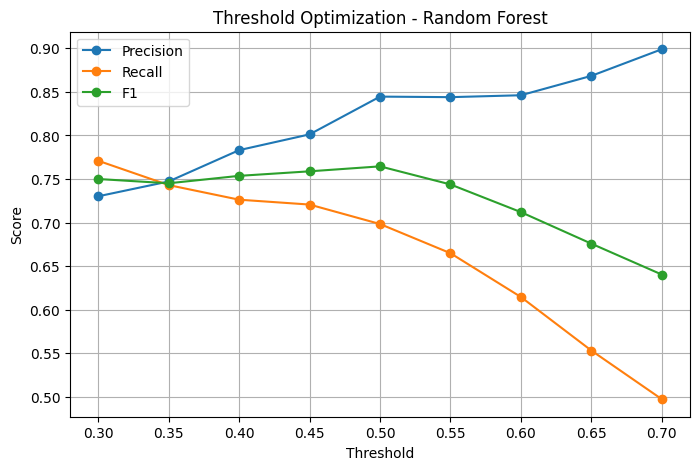

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
threshold_df.to_csv(
    "/content/drive/MyDrive/MPhil_Diabetes_Thesis/03_Results/threshold_results_rf.csv",
    index=False
)

Brier Score: 0.0381


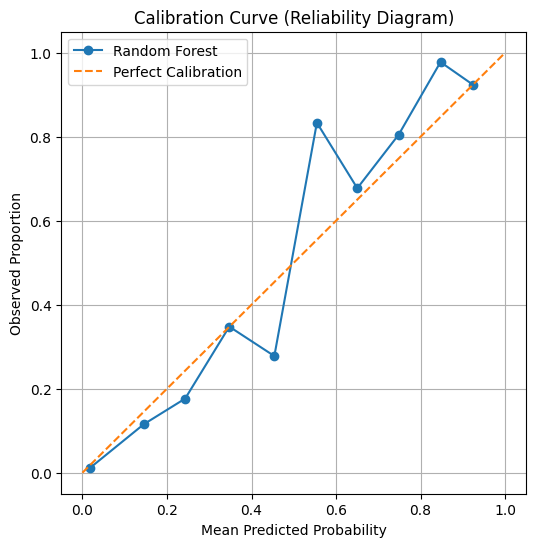

In [51]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Brier Score
brier = brier_score_loss(y_test, rf_prob)

print("Brier Score:", round(brier,4))

# Calibration Curve
prob_true, prob_pred = calibration_curve(
    y_test,
    rf_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker="o", label="Random Forest")
plt.plot([0,1],[0,1],"--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend()
plt.grid(True)

plt.show()

In [52]:
import numpy as np
import pandas as pd

# Copy dataset
df_fs = df.copy()

# Remove obvious non-predictive columns
drop_cols = [
    "SEQN",          # Participant ID
    "target"         # Target variable
]

X_all = df_fs.drop(columns=drop_cols, errors="ignore")
y_all = df_fs["target"]

print("Features:", X_all.shape[1])

Features: 16


In [53]:
X_all = X_all.select_dtypes(include=[np.number])

print("Numeric Features:", X_all.shape)

Numeric Features: (8709, 16)


In [54]:
missing = X_all.isnull().mean()

X_all = X_all.loc[:, missing < 0.40]

print("Remaining Features:", X_all.shape)

Remaining Features: (8709, 16)


In [55]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")

X_imp = pd.DataFrame(
    imp.fit_transform(X_all),
    columns=X_all.columns
)

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imp, y_all)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [57]:
importance = pd.DataFrame({
    "Feature": X_imp.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
10,LBXGH,0.373565
9,LBXGLU,0.112375
0,RIDAGEYR,0.099236
12,LBXTC,0.056702
6,BMXWAIST,0.055381
5,BMXBMI,0.051374
4,INDFMPIR,0.043650
11,LBDHDD,0.040756
7,BPXSY1,0.039361
8,BPXDI1,0.032280


In [58]:
importance.to_csv(
    "/content/drive/MyDrive/MPhil_Diabetes_Thesis/03_Results/feature_importance_all.csv",
    index=False
)

In [59]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/MPhil_Diabetes_Thesis/01_Data/NHANES/final_nhanes.csv")

print(df.shape)

(9254, 209)


In [60]:
# Separate features and target
X = df.drop(columns=["SEQN", "target"], errors="ignore")
y = df["target"]

print("Original Features:", X.shape[1])

Original Features: 207


In [61]:
import numpy as np

X = X.select_dtypes(include=[np.number])

print("Numeric Features:", X.shape[1])

Numeric Features: 205


In [62]:
missing_percent = X.isnull().mean()

X = X.loc[:, missing_percent < 0.70]

print("Remaining Features:", X.shape[1])

Remaining Features: 204


In [63]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(X_imputed.shape)

(9254, 204)


In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imputed, y)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [65]:
importance = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.reset_index(drop=True, inplace=True)

importance.head(50)

,Feature,Importance
0,DIQ010,0.172796
1,DIQ070,0.086288
2,DIQ300S,0.075603
3,DIQ300D,0.071612
4,DID040,0.068995
5,DID341,0.059754
6,DIQ280,0.045959
7,DID260,0.044105
8,DIQ230,0.043651
9,DID330,0.036418


In [66]:
importance.to_csv(
    "/content/drive/MyDrive/MPhil_Diabetes_Thesis/03_Results/All_Feature_Ranking.csv",
    index=False
)

print("Feature ranking saved successfully!")

Feature ranking saved successfully!


In [67]:
# Make a copy
df_f4 = df.copy()

# Remove all Diabetes Questionnaire variables (DIQ and DID)
remove_cols = []

for col in df_f4.columns:
    if col.startswith("DIQ") or col.startswith("DID"):
        remove_cols.append(col)

# Keep the target
if "target" in df_f4.columns:
    pass

df_f4 = df_f4.drop(columns=remove_cols, errors="ignore")

print("Remaining Columns:", df_f4.shape[1])

Remaining Columns: 156


In [68]:
drop_admin = [
    "SEQN",
    "SDDSRVYR",
    "RIDSTATR",
    "RIDAGEMN",
    "RIDEXMON",
    "RIDEXAGM"
]

df_f4.drop(columns=drop_admin, inplace=True, errors="ignore")

print(df_f4.shape)

(9254, 150)


In [69]:
import numpy as np

X = df_f4.drop(columns=["target"])
y = df_f4["target"]

X = X.select_dtypes(include=[np.number])

print(X.shape)

(9254, 147)


In [70]:
missing = X.isnull().mean()

X = X.loc[:, missing < 0.40]

print(X.shape)

(9254, 146)


In [71]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")

X_imp = pd.DataFrame(
    imp.fit_transform(X),
    columns=X.columns
)

print(X_imp.shape)

(9254, 146)


In [72]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")

X_imp = pd.DataFrame(
    imp.fit_transform(X),
    columns=X.columns
)

print(X_imp.shape)

(9254, 146)


In [73]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imp, y)

importance = pd.DataFrame({
    "Feature": X_imp.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance.head(40)

,Feature,Importance
0,LBXGH,0.199825
1,LBDGLUSI,0.055935
2,LBXGLU,0.050844
3,RIDAGEYR,0.040538
4,BMXWAIST,0.020744
5,LBDTCSI,0.018397
6,LBXTC,0.017880
7,DMDHHSZE,0.017093
8,BMXBMI,0.016902
9,WTINT2YR,0.016583


In [74]:
# Average systolic BP
df["BP_SYS_AVG"] = df[
    ["BPXSY1","BPXSY2","BPXSY3","BPXSY4"]
].mean(axis=1)

# Average diastolic BP
df["BP_DIA_AVG"] = df[
    ["BPXDI1","BPXDI2","BPXDI3","BPXDI4"]
].mean(axis=1)

In [75]:
features_f4 = [

"RIDAGEYR",
"RIAGENDR",
"RIDRETH3",
"DMDEDUC2",
"INDFMPIR",

"BMXBMI",
"BMXWAIST",
"BMXHIP",

"BP_SYS_AVG",
"BP_DIA_AVG",

"LBXGLU",
"LBXGH",
"LBDHDD",
"LBXTC",
"LBXTR",

"SMQ020",
"PAQ650",

"ALQ111"

]

df[features_f4].isnull().sum()

KeyError: "['ALQ111'] not in index"

In [76]:
[col for col in df.columns if col.startswith("ALQ")]

[]

In [77]:
[col for col in df.columns if col.startswith("BPXSY")]

['BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXSY4']

In [78]:
[col for col in df.columns if col.startswith("BPXDI")]

['BPXDI1', 'BPXDI2', 'BPXDI3', 'BPXDI4']

In [79]:
[col for col in df.columns if col.startswith("BMX")]

['BMXWT',
 'BMXRECUM',
 'BMXHEAD',
 'BMXHT',
 'BMXBMI',
 'BMXLEG',
 'BMXARML',
 'BMXARMC',
 'BMXWAIST',
 'BMXHIP']

In [80]:
# Average Systolic BP
df["BP_SYS_AVG"] = df[
    ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]
].mean(axis=1)

# Average Diastolic BP
df["BP_DIA_AVG"] = df[
    ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]
].mean(axis=1)

In [81]:
features_f4 = [

    # Demographics
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",

    # Body measurements
    "BMXBMI",
    "BMXWAIST",
    "BMXHIP",

    # Average blood pressure
    "BP_SYS_AVG",
    "BP_DIA_AVG",

    # Laboratory
    "LBXGLU",
    "LBXGH",
    "LBDHDD",
    "LBXTC",
    "LBXTR",

    # Lifestyle
    "SMQ020",
    "PAQ650"
]

target = "target"

In [82]:
summary = pd.DataFrame({
    "Missing": df[features_f4].isnull().sum(),
    "Missing %": (df[features_f4].isnull().mean()*100).round(2)
})

summary

,Missing,Missing %
RIDAGEYR,0,0.0
RIAGENDR,0,0.0
RIDRETH3,0,0.0
DMDEDUC2,0,0.0
INDFMPIR,0,0.0
BMXBMI,0,0.0
BMXWAIST,0,0.0
BMXHIP,0,0.0
BP_SYS_AVG,0,0.0
BP_DIA_AVG,0,0.0


In [83]:
summary = pd.DataFrame({
    "Missing": df[features_f4].isnull().sum(),
    "Missing %": (df[features_f4].isnull().mean()*100).round(2)
})

summary

,Missing,Missing %
RIDAGEYR,0,0.0
RIAGENDR,0,0.0
RIDRETH3,0,0.0
DMDEDUC2,0,0.0
INDFMPIR,0,0.0
BMXBMI,0,0.0
BMXWAIST,0,0.0
BMXHIP,0,0.0
BP_SYS_AVG,0,0.0
BP_DIA_AVG,0,0.0


In [84]:
X_f4 = df[features_f4]
y = df["target"]

print("Feature Shape:", X_f4.shape)
print("Target Shape :", y.shape)

Feature Shape: (9254, 17)
Target Shape : (9254,)


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_f4,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7403, 17)
(1851, 17)


In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000, random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "SVM":
    SVC(probability=True, random_state=42),

    "XGBoost":
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Framework":"Framework_4",

        "Model":name,

        "Accuracy":accuracy_score(y_test,y_pred),

        "Precision":precision_score(y_test,y_pred),

        "Recall":recall_score(y_test,y_pred),

        "F1":f1_score(y_test,y_pred),

        "ROC_AUC":roc_auc_score(y_test,y_prob),

        "PR_AUC":average_precision_score(y_test,y_prob)

    })

results_f4 = pd.DataFrame(results)

results_f4

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Framework,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Framework_4,Logistic Regression,0.947056,0.813953,0.586592,0.681818,0.949744,0.721557
1,Framework_4,Random Forest,0.937871,0.702532,0.620112,0.658754,0.947923,0.698282
2,Framework_4,SVM,0.917882,0.813953,0.195531,0.315315,0.907440,0.543603
3,Framework_4,XGBoost,0.937871,0.697531,0.631285,0.662757,0.947425,0.696712


In [88]:
results_f4.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Framework,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Framework_4,Logistic Regression,0.947056,0.813953,0.586592,0.681818,0.949744,0.721557
1,Framework_4,Random Forest,0.937871,0.702532,0.620112,0.658754,0.947923,0.698282
3,Framework_4,XGBoost,0.937871,0.697531,0.631285,0.662757,0.947425,0.696712
2,Framework_4,SVM,0.917882,0.813953,0.195531,0.315315,0.907440,0.543603


In [91]:
results_f4.sort_values(by="ROC_AUC", ascending=False)

,Framework,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Framework_4,Logistic Regression,0.947056,0.813953,0.586592,0.681818,0.949744,0.721557
1,Framework_4,Random Forest,0.937871,0.702532,0.620112,0.658754,0.947923,0.698282
3,Framework_4,XGBoost,0.937871,0.697531,0.631285,0.662757,0.947425,0.696712
2,Framework_4,SVM,0.917882,0.813953,0.195531,0.315315,0.907440,0.543603


In [93]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_results = cross_validate(
    best_rf,
    X_f3,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "Mean":[

        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_average_precision"].mean()

    ],

    "Std":[

        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_average_precision"].std()

    ]

})

cv_summary

NameError: name 'X_f3' is not defined

In [94]:
%whos

Variable                  Type                      Data/Info
-------------------------------------------------------------
GridSearchCV              ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression        type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                       ABCMeta                   <class 'sklearn.svm._classes.SVC'>
SimpleImputer             type                      <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold           ABCMeta                   <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
X                         DataFrame                       RIAGENDR  RIDAGEYR <...>[9254 rows x 146 columns]
XGBClassifier             type              

In [95]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_results = cross_validate(
    best_rf,
    X_all,
    y_all,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "Mean":[
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_average_precision"].mean()
    ],

    "Std":[
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_average_precision"].std()
    ]

})

cv_summary

,Metric,Mean,Std
0,Accuracy,0.947870,0.004242
1,Precision,0.817174,0.009705
2,Recall,0.632678,0.042801
3,F1,0.712608,0.030703
4,ROC_AUC,0.954725,0.007473
5,PR_AUC,0.786175,0.019507


In [96]:
cv_summary.to_csv(
"/content/drive/MyDrive/MPhil_Diabetes_Thesis/03_Results/CrossValidation_RF.csv",
index=False
)